### Import

In [2]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### All Collision Dataset

In [3]:
gdf = gpd.read_file('data/cleaned/Collision_All_Filtered.geojson')
gdf

,COLDETKEY,LOCATION,SEVERITYCODE,SEVERITYDESC,PERSONCOUNT,PEDCOUNT,PEDCYLCOUNT,VEHCOUNT,INJURIES,SERIOUSINJURIES,...,WEATHER,ROADCOND,LIGHTCOND,YEAR,MONTH,DAY,HOUR,Day_of_Week,Season,geometry
0,109700,SAND POINT WAY NE AND NE WINDERMERE RD,1,Property Damage Only Collision,5,0,0,2,0,0,...,Clear,Dry,Daylight,2010,10,13,8.0,Wednesday,Fall,POINT (-122.27108 47.66996)
1,190780,W DRAVUS ST BETWEEN 39TH AVE W AND 40TH AVE W,0,Unknown,0,0,0,0,0,0,...,Unknown,Unknown,Unknown,2014,11,29,NaN,Saturday,Fall,POINT (-122.40736 47.64863)
2,130100,35TH AVE NE BETWEEN NE 55TH ST AND NE 57TH ST,1,Property Damage Only Collision,4,0,0,2,0,0,...,Raining,Wet,Daylight,2011,1,24,17.0,Monday,Winter,POINT (-122.2902 47.66942)
3,166620,EAST GREEN LAKE WAY N BETWEEN 1ST AVE NE AND 2...,2,Injury Collision,2,0,0,2,1,0,...,Clear,Dry,Daylight,2014,4,25,7.0,Friday,Spring,POINT (-122.32789 47.67833)
4,139800,14TH AVE NW AND NW LEARY WAY,2,Injury Collision,2,0,0,2,1,0,...,Clear,Dry,Daylight,2012,1,5,9.0,Thursday,Winter,POINT (-122.37359 47.66366)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259239,380637,S DAKOTA ST BETWEEN 29TH AVE S AND M L KING JR...,0,Unknown,2,0,0,0,0,0,...,Unknown,Unknown,Unknown,2025,1,1,NaN,Wednesday,Winter,POINT (-122.29737 47.56618)
259240,381416,NW 75TH ST BETWEEN 24TH AVE NW AND 25TH AVE NW,0,Unknown,0,0,0,0,0,0,...,Unknown,Unknown,Unknown,2025,2,21,NaN,Friday,Winter,POINT (-122.38813 47.68316)
259241,379317,2ND AVE AND CHERRY ST,1,Property Damage Only Collision,3,0,0,2,0,0,...,Overcast,Wet,Daylight,2024,11,22,11.0,Friday,Fall,POINT (-122.33317 47.60302)
259242,381437,MINOR AVE BETWEEN HOWELL ST AND STEWART ST,1,Property Damage Only Collision,2,0,0,2,0,0,...,Overcast,Dry,Dark - Street Lights On,2025,3,4,4.0,Tuesday,Spring,POINT (-122.33121 47.61723)


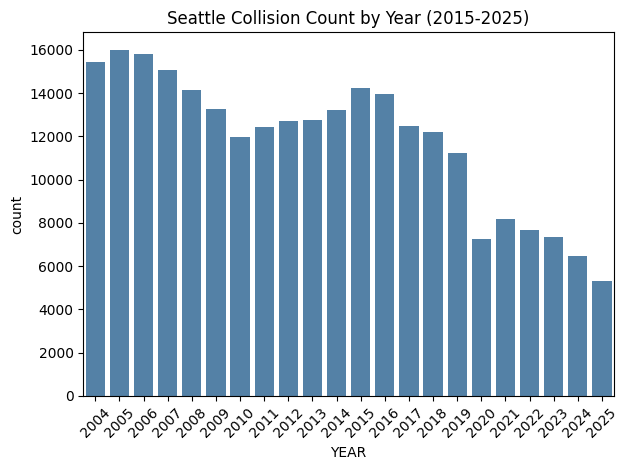

In [4]:
sns.countplot(gdf, x='YEAR', color='steelblue')
plt.title('Seattle Collision Count by Year (2015-2025)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

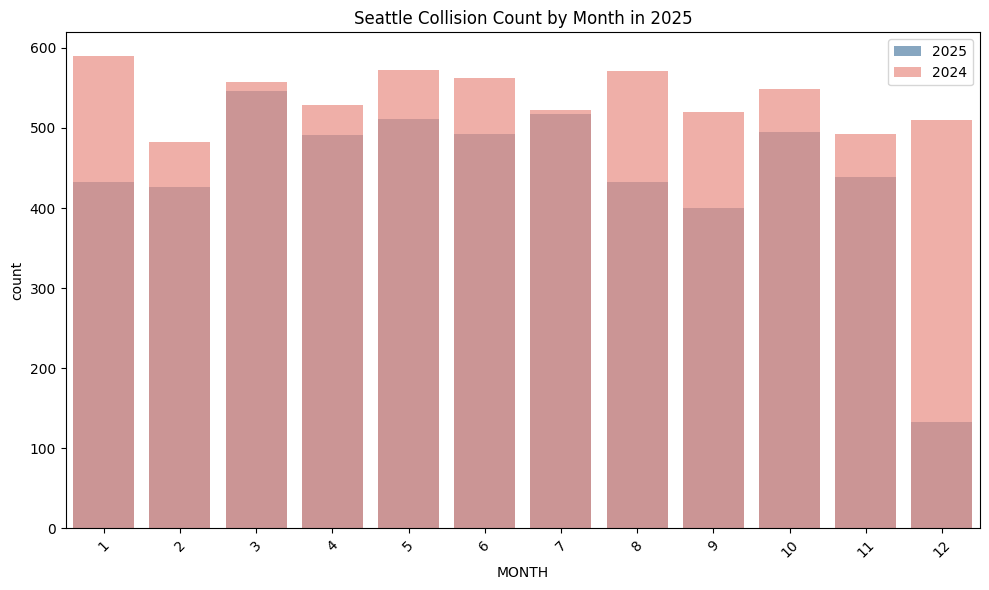

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.countplot(gdf[gdf['YEAR'] == 2025], x='MONTH', ax=ax, color='steelblue', label='2025', alpha=0.7)
sns.countplot(gdf[gdf['YEAR'] == 2024], x='MONTH', ax=ax, color='salmon', label='2024', alpha=0.7)
plt.title('Seattle Collision Count by Month in 2025')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

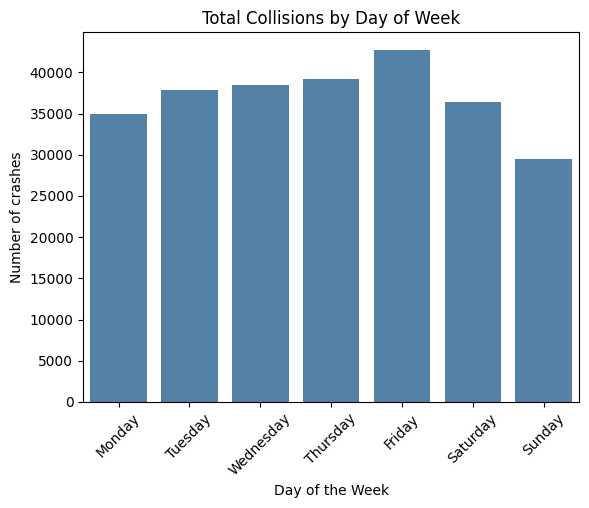

In [18]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

sns.countplot(gdf, x='Day_of_Week', order=day_order, color='steelblue')
plt.title('Total Collisions by Day of Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of crashes')
plt.xticks(rotation=45)
plt.show()

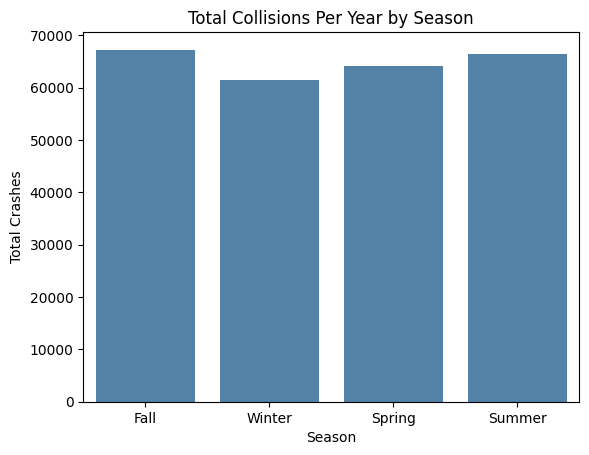

In [19]:
order = ['Fall', 'Winter', 'Spring', 'Summer']
sns.countplot(gdf, x='Season', order=order, color='steelblue')
plt.title('Total Collisions Per Year by Season')
plt.xlabel('Season')
plt.ylabel('Total Crashes')
plt.show()

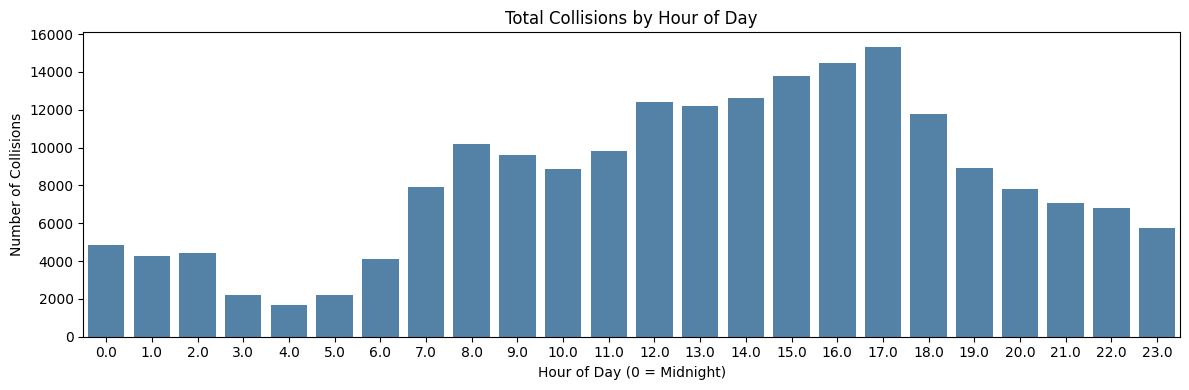

In [20]:
plt.figure(figsize=(12, 4))
hour_counts = gdf.groupby('HOUR').size().reset_index(name='COUNT')
sns.barplot(data=hour_counts, x='HOUR', y='COUNT', color='steelblue')
plt.title('Total Collisions by Hour of Day')
plt.xlabel('Hour of Day (0 = Midnight)')
plt.ylabel('Number of Collisions')
plt.tight_layout()
plt.show()

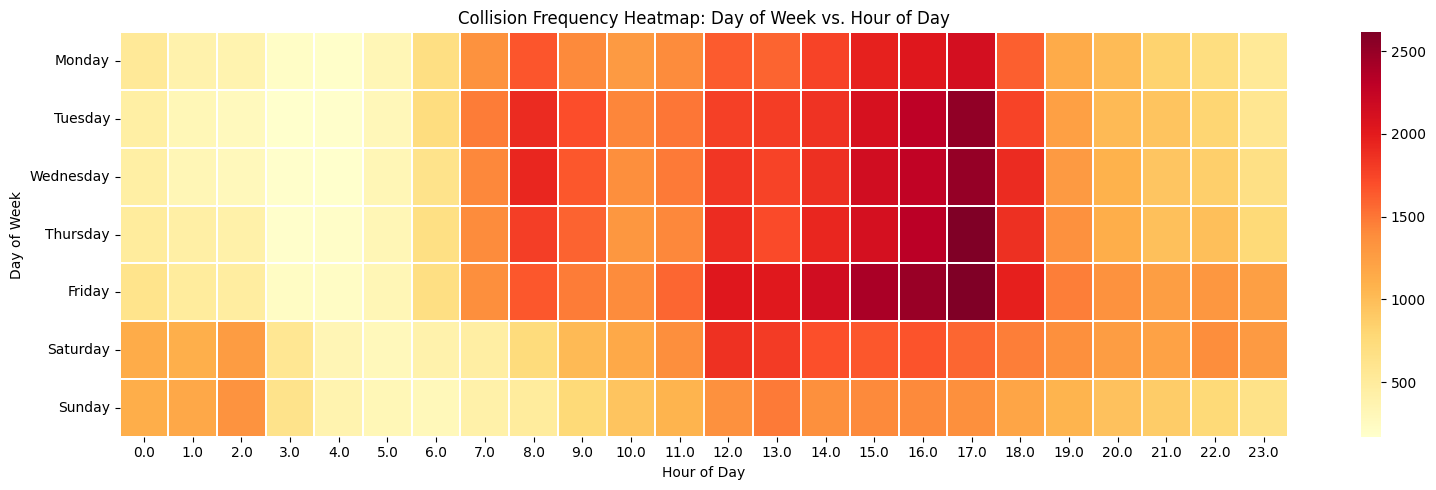

In [21]:
heatmap_data = (
    gdf.groupby(['Day_of_Week', 'HOUR'])
    .size()
    .reset_index(name='COUNT')
)
heatmap_pivot = heatmap_data.pivot(index='Day_of_Week', columns='HOUR', values='COUNT')
heatmap_pivot = heatmap_pivot.reindex(day_order)

plt.figure(figsize=(16, 5))
sns.heatmap(heatmap_pivot, cmap='YlOrRd', linewidths=0.3, annot=False)
plt.title('Collision Frequency Heatmap: Day of Week vs. Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.show()

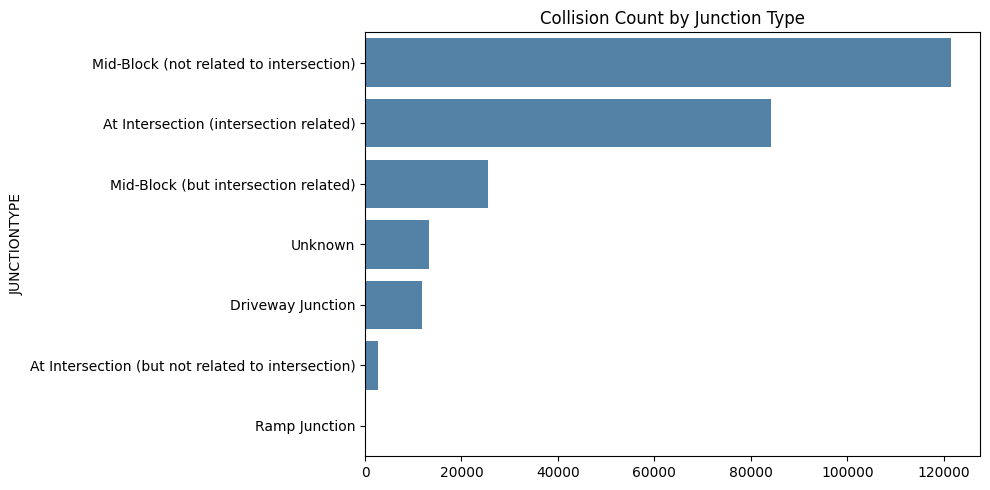

In [30]:
plt.figure(figsize=(10,5))
gdf_junc = gdf.groupby('JUNCTIONTYPE').size().sort_values(ascending=False)
sns.barplot(y=gdf_junc.index, x=gdf_junc.values, color='steelblue')
plt.title('Collision Count by Junction Type')
plt.tight_layout()
plt.show()

/var/folders/kg/syn5dsfn40l0n2qfhr_8whqh0000gn/T/ipykernel_11977/1894276878.py:12: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:steelblue'` for the same effect.

  sns.barplot(data=junc_period, x='JUNCTIONTYPE', y='PROPORTION', hue='PERIOD', color='steelblue')


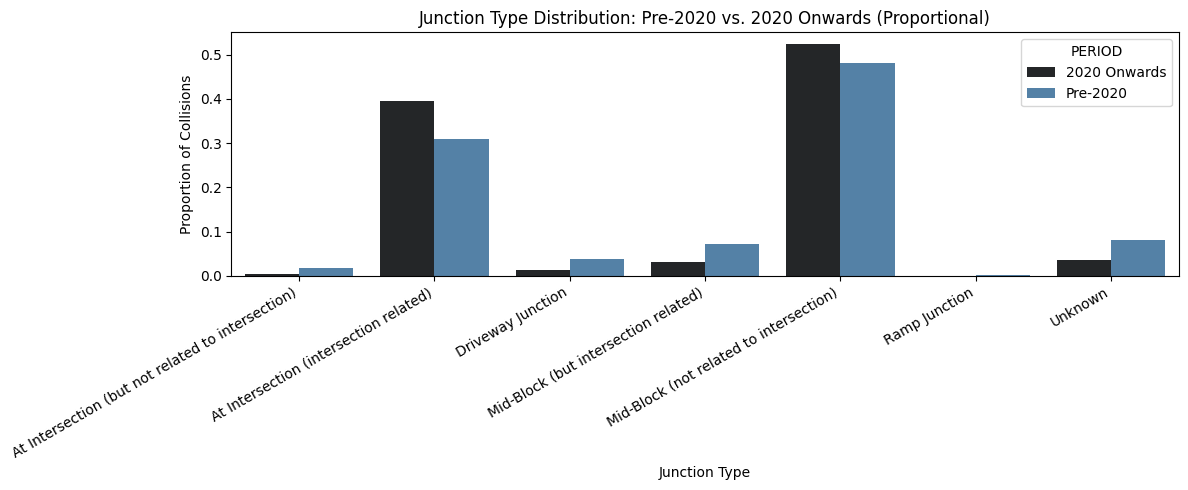

In [43]:
gdf_filtered = gdf[gdf['YEAR'] >= 2015].copy()
gdf_filtered['PERIOD'] = gdf_filtered['YEAR'].apply(lambda y: 'Pre-2020' if y < 2020 else '2020 Onwards')

junc_period = (
    gdf_filtered.groupby(['PERIOD', 'JUNCTIONTYPE'])
    .size()
    .reset_index(name='COUNT')
)
junc_period['PROPORTION'] = junc_period.groupby('PERIOD')['COUNT'].transform(lambda x: x / x.sum())

plt.figure(figsize=(12, 5))
sns.barplot(data=junc_period, x='JUNCTIONTYPE', y='PROPORTION', hue='PERIOD', color='steelblue')
plt.title('Junction Type Distribution: Pre-2020 vs. 2020 Onwards (Proportional)')
plt.xlabel('Junction Type')
plt.ylabel('Proportion of Collisions')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

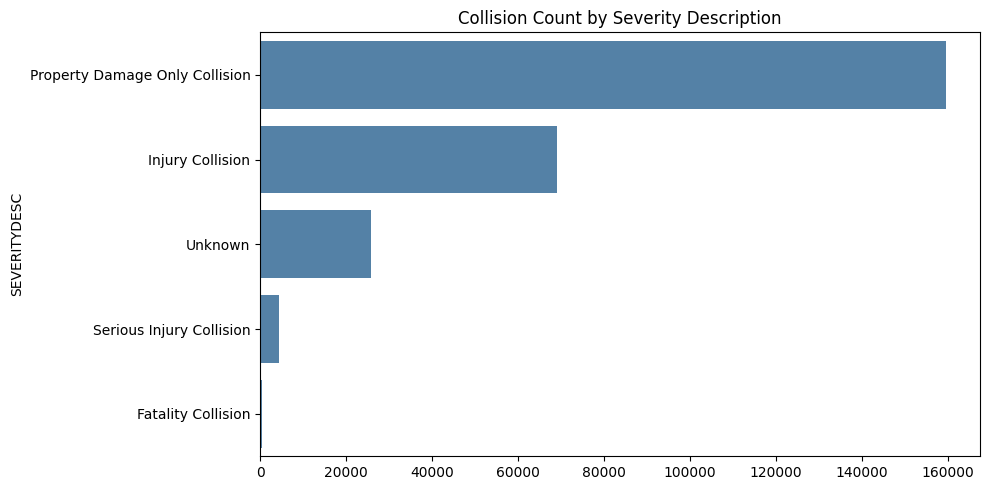

In [44]:
plt.figure(figsize=(10,5))
gdf_sev = gdf.groupby('SEVERITYDESC').size().sort_values(ascending=False)
sns.barplot(y=gdf_sev.index, x=gdf_sev.values, color='steelblue')
plt.title('Collision Count by Severity Description')
plt.tight_layout()
plt.show()

/var/folders/kg/syn5dsfn40l0n2qfhr_8whqh0000gn/T/ipykernel_11977/2239289380.py:9: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:steelblue'` for the same effect.

  sns.barplot(data=severity_period, x='SEVERITYDESC', y='PROPORTION', hue='PERIOD', color='steelblue')


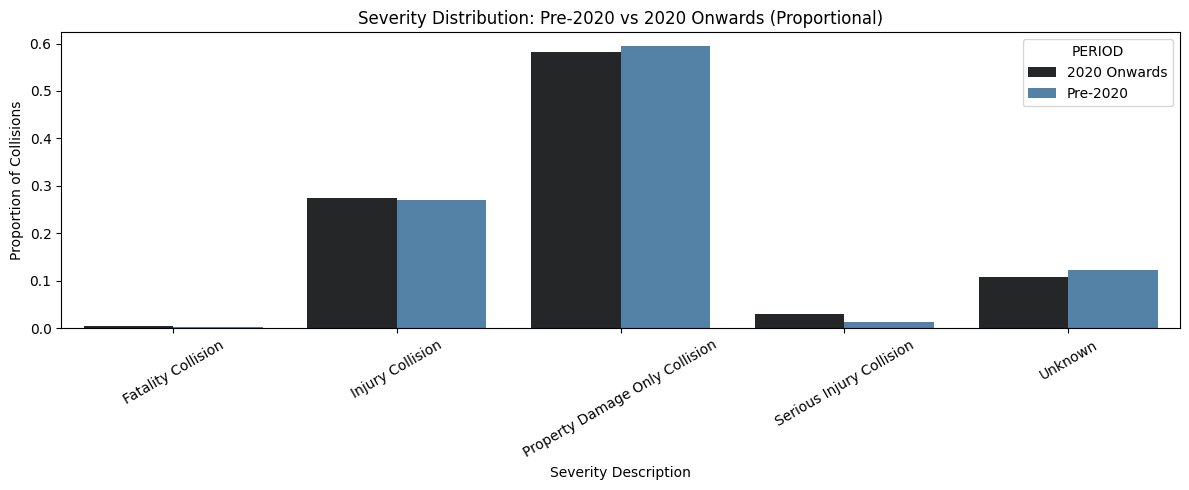

In [45]:
severity_period = (
    gdf_filtered.groupby(['PERIOD', 'SEVERITYDESC'])
    .size()
    .reset_index(name='COUNT')
)
severity_period['PROPORTION'] = severity_period.groupby('PERIOD')['COUNT'].transform(lambda x: x / x.sum())

plt.figure(figsize=(12, 5))
sns.barplot(data=severity_period, x='SEVERITYDESC', y='PROPORTION', hue='PERIOD', color='steelblue')
plt.title('Severity Distribution: Pre-2020 vs 2020 Onwards (Proportional)')
plt.xlabel('Severity Description')
plt.ylabel('Proportion of Collisions')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

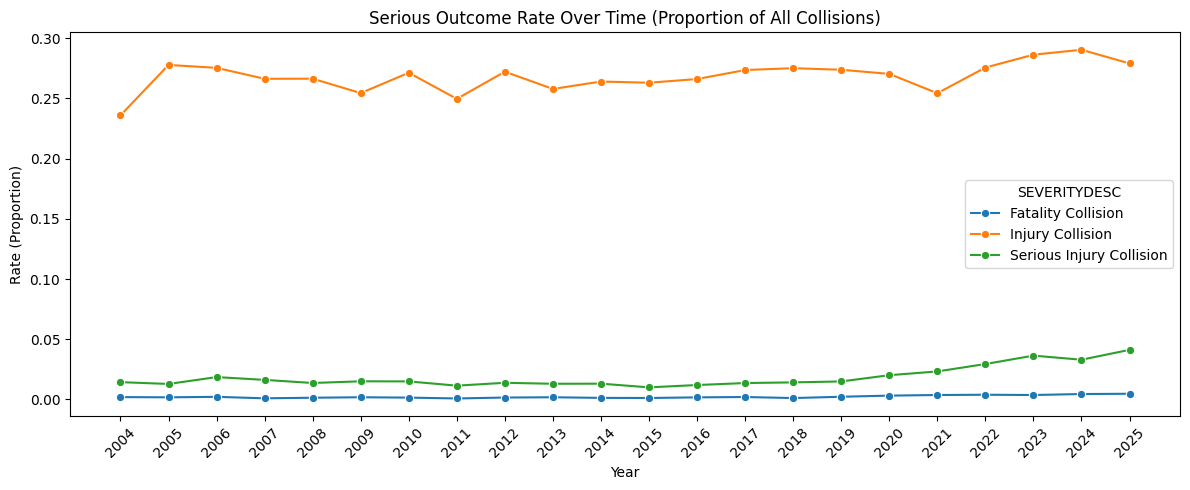

In [46]:
severity_year = (
    gdf.groupby(['YEAR', 'SEVERITYDESC'])
    .size()
    .reset_index(name='COUNT')
)
severity_year['TOTAL'] = severity_year.groupby('YEAR')['COUNT'].transform('sum')
severity_year['RATE'] = severity_year['COUNT'] / severity_year['TOTAL']

serious = severity_year[severity_year['SEVERITYDESC'].str.contains('Injury|Fatal', case=False, na=False)]

plt.figure(figsize=(12, 5))
sns.lineplot(data=serious, x='YEAR', y='RATE', hue='SEVERITYDESC', marker='o')
plt.title('Serious Outcome Rate Over Time (Proportion of All Collisions)')
plt.xlabel('Year')
plt.ylabel('Rate (Proportion)')
plt.xticks(sorted(serious['YEAR'].unique()), rotation=45)
plt.tight_layout()
plt.show()

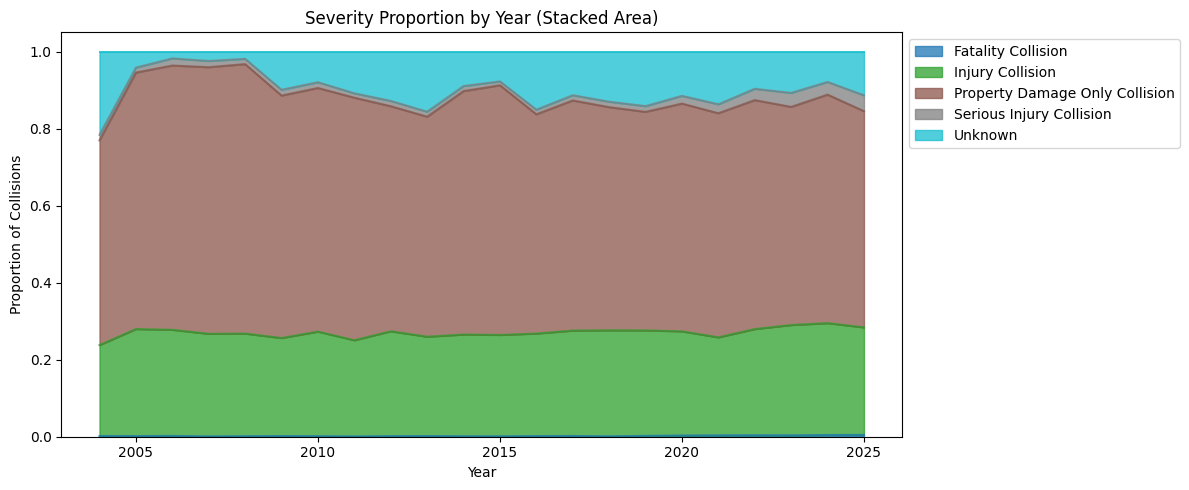

In [47]:
severity_pivot = severity_year.pivot(index='YEAR', columns='SEVERITYDESC', values='RATE').fillna(0)

severity_pivot.plot(kind='area', stacked=True, figsize=(12, 5), alpha=0.75, colormap='tab10')
plt.title('Severity Proportion by Year (Stacked Area)')
plt.xlabel('Year')
plt.ylabel('Proportion of Collisions')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

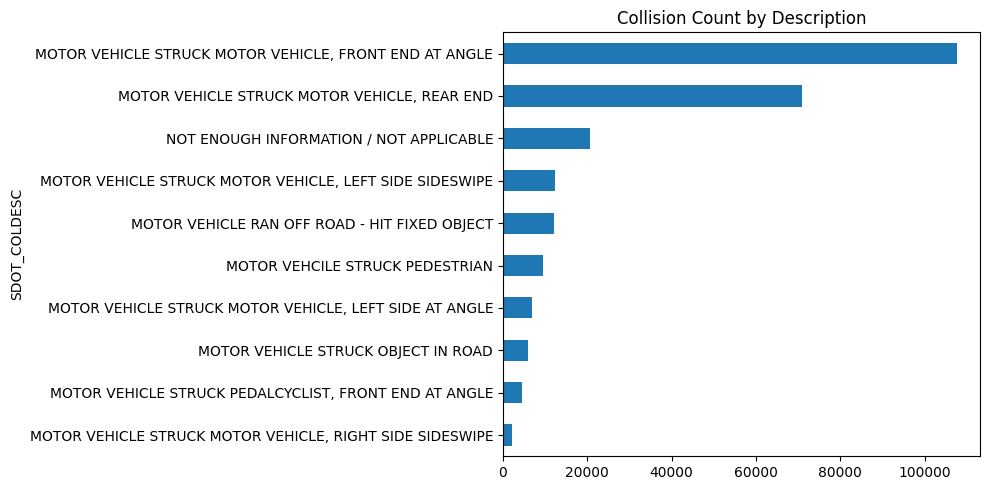

In [14]:
plt.figure(figsize=(10,5))
gdf_sev = gdf.groupby('SDOT_COLDESC').size().sort_values(ascending=False).head(10).sort_values(ascending=True)
gdf_sev.plot(kind='barh')
plt.title('Collision Count by Description')
plt.tight_layout()
plt.show()

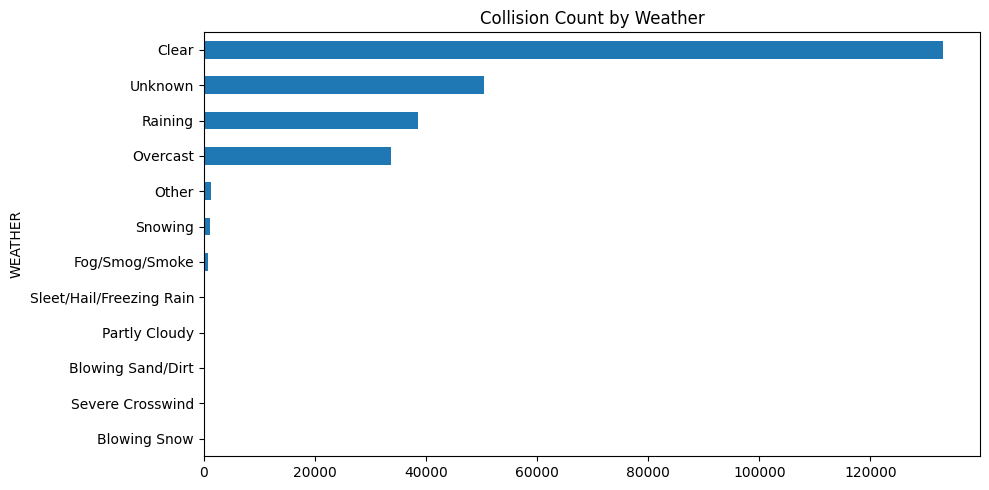

In [15]:
plt.figure(figsize=(10,5))
gdf_sev = gdf.groupby('WEATHER').size().sort_values(ascending=True)
gdf_sev.plot(kind='barh')
plt.title('Collision Count by Weather')
plt.tight_layout()
plt.show()

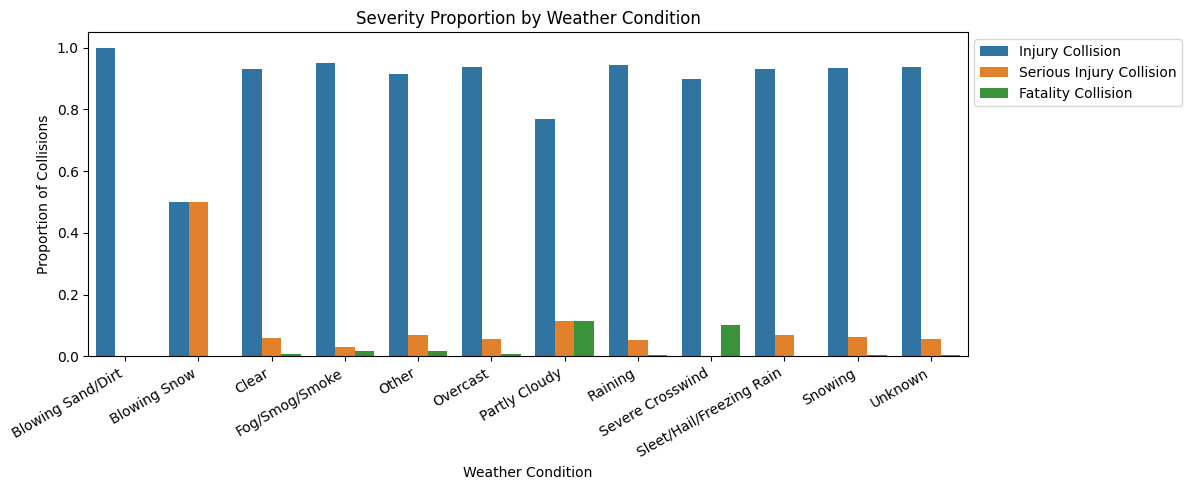

In [73]:
weather_sev = (
    gdf.groupby(['WEATHER', 'SEVERITYDESC'])
    .size()
    .reset_index(name='COUNT')
)
weather_sev = weather_sev[weather_sev['SEVERITYDESC'].str.contains('Injury|Fatal')]
weather_sev['PROPORTION'] = weather_sev.groupby('WEATHER')['COUNT'].transform(lambda x: x / x.sum())

plt.figure(figsize=(12, 5))
sns.barplot(data=weather_sev, x='WEATHER', y='PROPORTION', hue='SEVERITYDESC')
plt.title('Severity Proportion by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Proportion of Collisions')
plt.xticks(rotation=30, ha='right')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

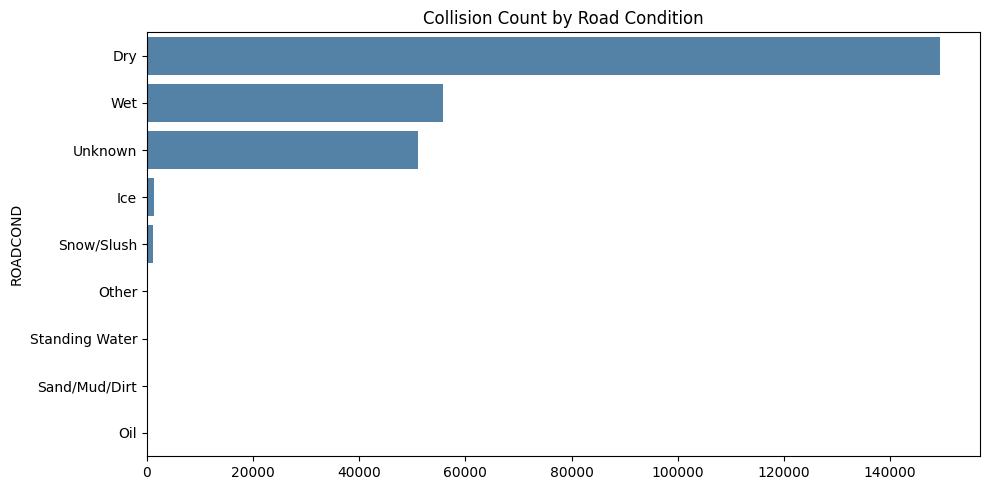

In [56]:
plt.figure(figsize=(10,5))
gdf_sev = gdf.groupby('ROADCOND').size().sort_values(ascending=False)
sns.barplot(y=gdf_sev.index, x=gdf_sev.values, color='steelblue')
plt.title('Collision Count by Road Condition')
plt.tight_layout()
plt.show()

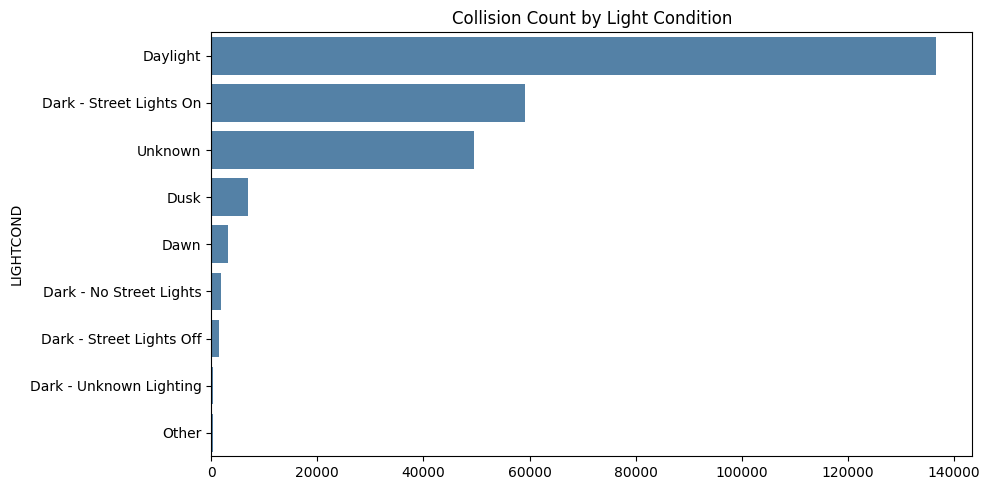

In [58]:
plt.figure(figsize=(10,5))
gdf_sev = gdf.groupby('LIGHTCOND').size().sort_values(ascending=False)
sns.barplot(y=gdf_sev.index, x=gdf_sev.values, color='steelblue')
plt.title('Collision Count by Light Condition')
plt.tight_layout()
plt.show()

### Vehicle Collision Dataset

In [59]:
df_veh = pd.read_csv('data/cleaned/Vehicle_Filtered.csv')
df_veh

,COLDETKEY,ST_VEH_TYPE_DESC,YEAR
0,27800,Truck/SUV,2004
1,1194,Truck/SUV,2013
2,1194,Truck/SUV,2013
3,35300,Truck/SUV,2005
4,35300,Truck/SUV,2005
...,...,...,...
429568,379695,Two-Wheeled,2024
429569,379695,Passenger Vehicle,2024
429570,379817,Other,2024
429571,379817,Truck/SUV,2024


ST_VEH_TYPE_DESC
Buses                  5338
Commercial Trucks     13490
Other                 33351
Passenger Vehicle    234266
Truck/SUV            137986
Two-Wheeled            5142
dtype: int64


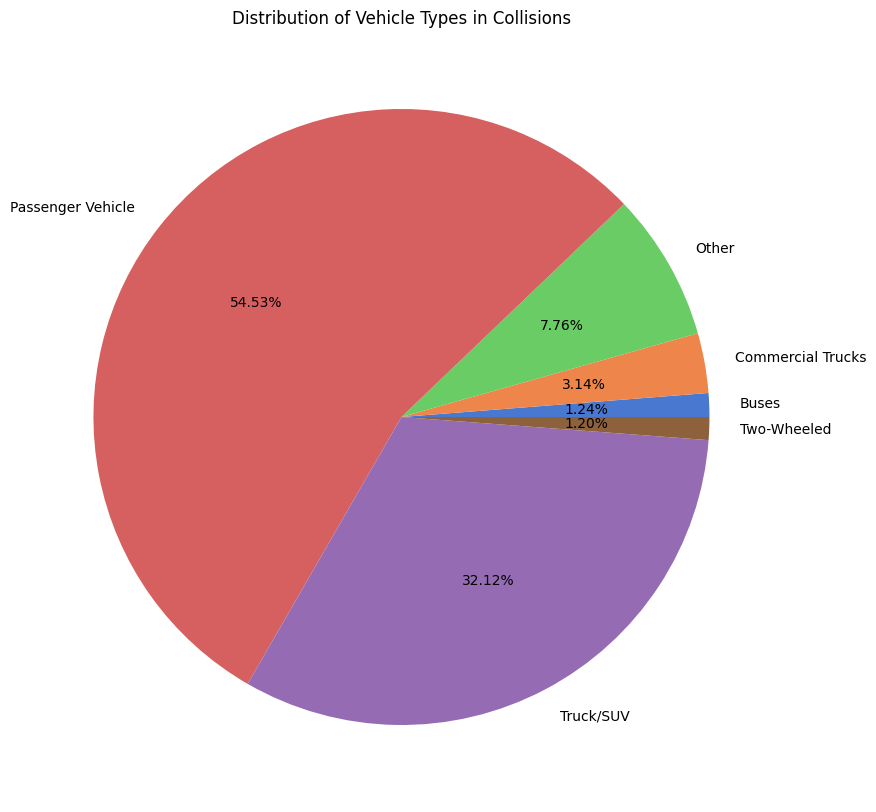

In [66]:
df_veh_size = df_veh.groupby('ST_VEH_TYPE_DESC').size()
print(df_veh_size)

labels = np.unique(df_veh_size.index)
plt.figure(figsize=(10,10))
plt.pie(df_veh_size, labels=labels, autopct='%.2f%%', colors=sns.color_palette('muted', len(labels)))
plt.title('Distribution of Vehicle Types in Collisions')
plt.show()

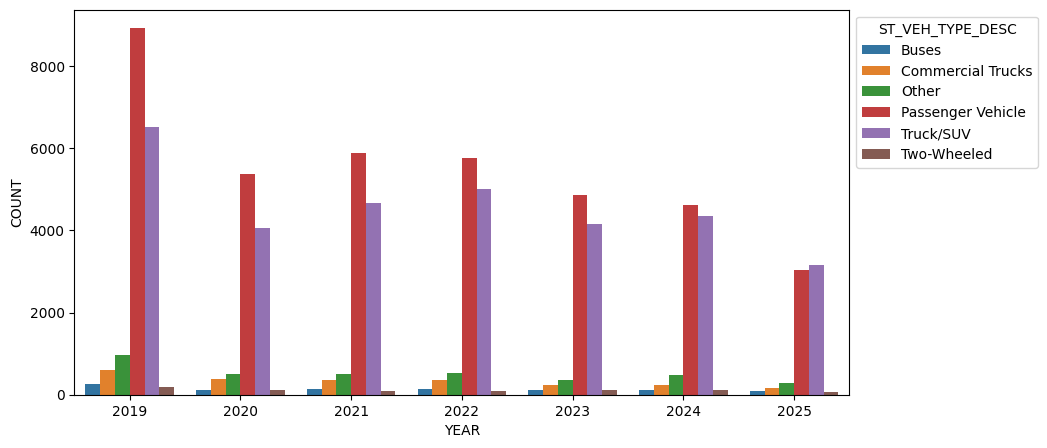

In [72]:
plt.figure(figsize=(10,5))
df_veh_group = pd.DataFrame(df_veh.groupby(['YEAR', 'ST_VEH_TYPE_DESC']).size().reset_index()).rename(columns={0: 'COUNT'})
df_veh_group = df_veh_group[df_veh_group['YEAR'] > 2018]

veh_plot = sns.barplot(data=df_veh_group, x='YEAR', y='COUNT', hue='ST_VEH_TYPE_DESC', legend=True)
sns.move_legend(
    veh_plot,
    'upper left',
    bbox_to_anchor=(1,1)
)
plt.tight_layout
plt.show()